# 19 The shipped winding thermometer

Notebook 17 showed the winding's copper is a thermometer, and notebook 18 gave it a two-node
thermal model. What ended up in the firmware is a bit different from both. It never trusts a
resistance as an absolute. The board's NTC thermistor (a resistor whose value drops as it warms, on
the board next to the motor) gives the absolute base. The ratio of the winding's resistance to
itself at one seat gives the change while the shaft holds still. And a first-order model carries
the winding's excess over the NTC between seats. The code is `estimator/thermal.rs` in the core
firmware, and docs/control-theory.md describes it.

This notebook grades that thermometer against a K thermocouple bead taped to the motor can, on the
rev 2A board with the bench MG90, fed by the DPS-150 at 7.4 V. The questions were:

1. Why can the thermometer only compare a resistance to itself at the same seat?
2. How far off is the carried temperature when the shaft comes back after a torque-off gap?
3. What happens when the contact steps inside a hold, and what do the guards do about it?
4. What does the thermometer read right after a reset, before it has any seat?
5. What do the family constants, 128 s and 63 C/W, actually mean, and which part of them did the
   bench pin?

If you are short on time, here is the quick version:

- **A resistance is only good against itself, at one seat.** At one stop the seat references
  carried to 25 C spread 1.96 to 2.69% from seat to seat, 5 to 7 C of copper. The afternoon's three
  anchors spread 3.71%, a stop that moved read 9% over the stored cold R, and twice the circuit sat
  about 20% low for seconds at a time (a brush bridging two commutator segments). One percent of R
  is 2.6 C. So the base is the NTC and the ratio only ever runs inside one hold.
- **The carry across a 240 s torque-off gap reads +0.05, +1.36 and +2.12 C over the can's truth**
  in the rep with the guards in, and +1.14 C on run 3's one clean gap. It reads high every time,
  and a little more each gap. After 30 s gaps it reads +3.06 and +5.30 C over the can, but there
  the can is no truth, since the winding has not cooled to it yet.
- **The base itself is off by 2.03 to 2.75 C.** At rest the board NTC sits that much over the can,
  and the shipped thermometer does not subtract it.
- **The guards turn a false 83 C into nothing.** Without them (run 3) a seat that started in the
  bridged state read 83.01 C with the can near 31 C and folded the current limit to 237 counts.
  With them (run 4) the same kind of seat was dropped twice, once by the rise check and once by
  the voltage band, each move under 1 C of carried temperature, and the limit never moved.
- **The boot prior reads 9.02 C over the NTC at the reset and is at 0.00 by 600 s**, against
  9.07 C predicted. After a warm reset and after a cold power-on the true excess was 2.67 and
  1.26 C, so the prior reads about 6.3 C high at first and is inside 1 C of the can by 240 s.
- **63 C/W is the winding over the air, the can to air is about 31 C/W.** Two 480 s holds put the
  can's settled rise at 30.9 and 32.4 C/W. The 63 is notebook 18's winding-over-air number. What
  the winding does over the can at the end of a hold depends on which clock the can's cool-down is
  read on, and the data does not settle it (section 6).

## Picking a rig

One dataset, `mg90-a__dev-v006-2A__dps__thermometer`. Its captures are logs of the firmware's own
telemetry, from `th` and `osc ident thermal`, so none of them carries a `sense` block, and the board
cannot be read off the data. The bench log says rev 2A board #1, the same unit as notebooks 14, 17
and 18, so I name it here.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import boards, datasets, servos, thermal as th, thermometer as tm

DS = datasets.load("mg90-a__dev-v006-2A__dps__thermometer")
# No capture here carries a sense block. The bench log names the board: rev 2A board #1, the
# same unit as notebooks 14, 17 and 18, on the DPS-150 at 7.4 V with the battery out.
board, servo = boards.BOARDS["dev-v006-2A"], servos.SERVOS["mg90-a"]
rig = oscnb.Rig(board, servo).show()

W_UNIT = board.v_term_per_count * board.a_per_count      # watts per vcount x ccount, the kernel's power unit
OHM_Q12 = board.v_term_per_count / board.a_per_count / 4096   # ohm per unit of a Q4.12 vcount/ccount resistance
K_CU = tm.COPPER_ZERO_C                                   # copper: R is proportional to (234.5 + T)
IX = tm.index(DS).set_index("capture")
REPO = Path.cwd().parent                                  # the notebook runs from notebooks/

# Every th log, meter and rest offset, loaded once.
OAB = {c: tm.th_log(DS, c, "oab") for c in ("oab/capture-1", "oab/capture-2")}
MET = {c: tm.meter(DS, c) for c in IX.index}
REST = {c: tm.rest_offset(tm.th_log(DS, c, "rest"), MET[c]) for c in ("oab/capture-1", "oab/capture-2",
                                                                       "thermal/capture-1", "thermal/capture-2")}
RUN = {c: tm.ident_run(DS, c, IX.loc[c, "unix0"]) for c in ("thermal/capture-1", "thermal/capture-2")}
BOOT = {c: tm.th_log(DS, c, "boot") for c in ("boot/capture-1", "boot/capture-2")}
SEAT = {c: tm.th_log(DS, c, "hold") for c in ("firstseat/capture-1", "firstseat/capture-2")}
print(f"watts per kernel power unit {W_UNIT:.4e}; ohm per Q4.12 unit {OHM_Q12:.5f}")
print(f"thermocouple packet interval, median over every capture: {np.median(np.concatenate([np.diff(m.t_unix) for m in MET.values()])):.2f} s; "
      f"th poll interval in the reps: {np.median(np.diff(OAB['oab/capture-2'].t_unix)) * 1e3:.1f} ms")
print("thermocouple packets dropped as out of range: " + ", ".join(f"{c} {m.attrs['dropped']}" for c, m in MET.items()))
display(IX[["image", "what"]])

Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1

  board: Rs1 60 mOhm; bare OPA with Rf 6k4 / Rg 430 (G 14.884), Cc 22 pF, Co1 DNP. Terminal taps Rv1/Rv3 6k4 over Rv2/Rv4 1k6 with Cv1/Cv2 100 pF, bottoms and caps returned to VB from Rb1 430 / Rb2 100 (773 counts nominal, about 81 ohm source, so VB rises with the leg current under drive). VSNS 6k4/1k6 to GND, unbiased, Cv3 100 pF. A 2A capture's sense block differs from board D's in gain_milli and both divider legs. Nothing in the block carries the bias or VSNS parts, or which 2A unit took the capture, so every 2A board shares this entry. Board #1 had Rv3 open for the grid-3r7 2S session: in that dataset tap B reads the VB node instead of terminal B, so only tap A, the rail and the current are graded there. Rv3 is repaired, and a dataset captured with it fitted reads both taps. Floors 64/93 ticks: the current at 3% with the settle gain on top (nb10 sec 8), the terminals from the grid ladder with tap B sampled 37 ticks before 

value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from                               % duty                  5.3333
                 voltage settled from                               % duty                  7.7500
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800

watts per kernel power unit 3.6342e-06; ohm per Q4.12 unit 0.00109
thermocouple packet interval, median over every capture: 0.51 s; th poll interval in the reps: 6.6 ms
thermocouple packets dropped as out of range: oab/capture-1 0, oab/capture-2 0, thermal/capture-1 0, thermal/capture-2 0, boot/capture-1 0, boot/capture-2 0, firstseat/capture-1 0, firstseat/capture-2 0


,image,what
capture,,
oab/capture-1,127d2bca,out-and-back rep without the v band or the ris...
oab/capture-2,a87d94ac,out-and-back rep with the guards
thermal/capture-1,bb9b0ceb,osc ident thermal hold (free fit)
thermal/capture-2,b4c4775b,osc ident thermal hold (g fit)
boot/capture-1,b4c4775b,reset after a warm hold
boot/capture-2,b4c4775b,power-on after a long rest
firstseat/capture-1,26f38948,first seat after a power-on at a moved stop
firstseat/capture-2,bb9b0ceb,first seat after a reset at the same stop


**What you are looking at.** The rig table, then the captures. They come from five firmware images,
because the thermometer was being built while it was being measured. The two out-and-back reps
(`oab`) ran before the guards landed (run 3) and with them (run 4). Run 4's image is the merged
thermometer. The thermometer changes after it touched only the boot rule (section 5), so run 4 grades
the shipped seat rules, carry and guards. The boot logs and the second thermal hold ran the shipped
image itself. The two first-seat holds ran the boot rule the shipped image replaced, and they are
here to show why. Every thermocouple packet of every capture was inside 10 to 80 C, so nothing was
dropped.

## 1. Why same-seat only

Copper's resistance is proportional to $(234.5 + T)$, so at 25 C one percent of R is 2.6 C. That
is the exchange rate for everything in this section. Anything else in series with the copper that
moves R by a percent reads as 2.6 C of heat that is not there.

The brush and commutator contact is in series with the copper, and it moves. To see by how much,
I took every seat reference the firmware formed in the two out-and-back reps, all at the low stop,
and carried each to 25 C along copper from the can's temperature at that moment (T*, section 3).
What is left after that is contact, not heat.

In [2]:
# 1% of R in degrees of copper at 25 C: the thermometer's exchange rate.
print(f"1% of R reads as {0.01 * (K_CU + 25):.2f} C at 25 C")

# Every seat reference of the two out-and-back reps, carried to 25 C along copper from T* (the can
# less the rest offset, section 3), so the heat in them drops out and what is left is contact.
rows = []
for c, log in OAB.items():
    b = tm.bases(log)
    b["t_star"] = tm.can_at(MET[c], b.t_unix.to_numpy()) - REST[c]["offset"]
    b["r25"] = b.r_hat * (K_CU + 25) / (K_CU + b.t_star)
    rows.append(b.assign(capture=c))
SEATS = pd.concat(rows, ignore_index=True)
SEATS["low"] = SEATS.r_hat < 0.9 * SEATS.r_hat.median()       # the bridged-segment state, section 4
display(SEATS[["capture", "hold", "n", "t_s", "r_hat", "t_star", "r25", "duty", "i", "low"]].round(2))
rows = []
for c, g in SEATS[~SEATS.low].groupby("capture"):
    rows.append({"set": f"{c}, one stop, normal state", "n": len(g), "R25 mean": g.r25.mean(),
                 "sd %": g.r25.std() / g.r25.mean() * 100, "max/min - 1 %": (g.r25.max() / g.r25.min() - 1) * 100})
    rows[-1]["range as C of copper"] = rows[-1]["max/min - 1 %"] / 100 * (K_CU + 25)
# the cold references the anchor step stored across the afternoon, each its own seat after a rest
anchors = {c: tm.calib_fields((DS.path / c / "anchor.out").read_text())["r0_q12"] for c in ("oab/capture-1", "oab/capture-2")}
anchors["the shipped board's first anchor"] = tm.calib_fields((DS.path / "anchor-m1.out").read_text())["r0_q12"]
a = np.array(list(anchors.values()), float)
rows.append({"set": "anchors (r0_q12 at 25 C)", "n": len(a), "R25 mean": a.mean(), "sd %": a.std(ddof=1) / a.mean() * 100,
             "max/min - 1 %": (a.max() / a.min() - 1) * 100, "range as C of copper": (a.max() / a.min() - 1) * (K_CU + 25)})
CONTACT = pd.DataFrame(rows).set_index("set")
display(CONTACT.round(2))
print("anchors: " + ", ".join(f"{k} {v}" for k, v in anchors.items()))
low = SEATS[SEATS.low]
for x in low.itertuples():
    ref = SEATS[(SEATS.capture == x.capture) & ~SEATS.low].r25.median()
    print(f"{x.capture} {x.hold} base {x.n}: R {x.r_hat} at duty {abs(x.duty) / 327.67:.1f}% and {x.i} counts, "
          f"{(x.r25 / ref - 1) * 100:+.1f}% against the normal seats' median")

1% of R reads as 2.60 C at 25 C


,capture,hold,n,t_s,r_hat,t_star,r25,duty,i,low
0,oab/capture-1,hold0,0,3.07,4107,30.05,4028.60,-5153,272,False
1,oab/capture-1,hold1,0,3.06,4109,30.95,4016.90,-5153,271,False
2,oab/capture-1,hold2,0,3.07,4181,33.25,4052.17,-5153,266,False
3,oab/capture-1,hold3,0,2.72,3279,31.05,3204.29,-4129,268,True
4,oab/capture-1,hold3,1,24.97,4156,31.45,4055.21,-4737,243,False
5,oab/capture-1,hold4,0,3.06,4146,32.95,4022.76,-5153,267,False
6,oab/capture-1,hold5,0,3.07,4070,31.05,3977.27,-5025,267,False
7,oab/capture-2,hold0,0,2.72,3209,28.03,3171.96,-4049,269,True
8,oab/capture-2,hold0,1,14.21,3304,28.23,3263.38,-4049,263,True
9,oab/capture-2,hold0,2,27.33,4137,28.73,4078.38,-5073,264,False


,n,R25 mean,sd %,max/min - 1 %,range as C of copper
set,,,,,
"oab/capture-1, one stop, normal state",6,4025.49,0.70,1.96,5.08
"oab/capture-2, one stop, normal state",6,4013.92,0.94,2.69,6.99
anchors (r0_q12 at 25 C),3,4010.33,1.83,3.71,9.64


anchors: oab/capture-1 4021, oab/capture-2 4078, the shipped board's first anchor 3932
oab/capture-1 hold3 base 0: R 3279 at duty 12.6% and 268 counts, -20.4% against the normal seats' median
oab/capture-2 hold0 base 0: R 3209 at duty 12.4% and 269 counts, -20.9% against the normal seats' median
oab/capture-2 hold0 base 1: R 3304 at duty 12.4% and 263 counts, -18.7% against the normal seats' median


**What you are looking at.** Every seat reference of both reps with its R in Q4.12 counts, the can's
temperature at the base, and R carried to 25 C. Then the spread per rep, and the three cold anchors
the anchor step stored that afternoon. Last, the references that sat in the low state.

- **At one stop the seats spread 1.96 to 2.69% max to min**, 0.70 and 0.94% standard deviation in
  run 3 and run 4. Read as temperature that is 5.08 and 6.99 C. The seats were the same stop, a few
  minutes apart, with nothing but a move out and back between them.
- **The anchors spread 3.71%.** Each is a seat after an 11 minute rest, carried to 25 C through the
  NTC, and they were taken a few hours apart.
- **Three references sat about 20% low**, -20.4, -20.9 and -18.7% against the normal seats, at a
  duty near 12.5% and the usual 263 to 269 counts. Section 4 is about that state.
- **Bigger and slower shifts are in the earlier notebooks.** Notebook 17 sec 5 found the whole
  burst R 3 to 4% high for hours after a rebuild and a cal, and notebook 18 sec 3 found 4 to 16%
  over copper for over an hour after hard running. Section 5 here has a first seat 9% over the
  stored cold R after the low stop moved.

So no stored resistance can be the base. A seat compared to itself is fine though, as long as the
contact holds still for the hold. That is the design. The NTC is the absolute, the ratio runs
only inside one hold, and a model carries the rest.

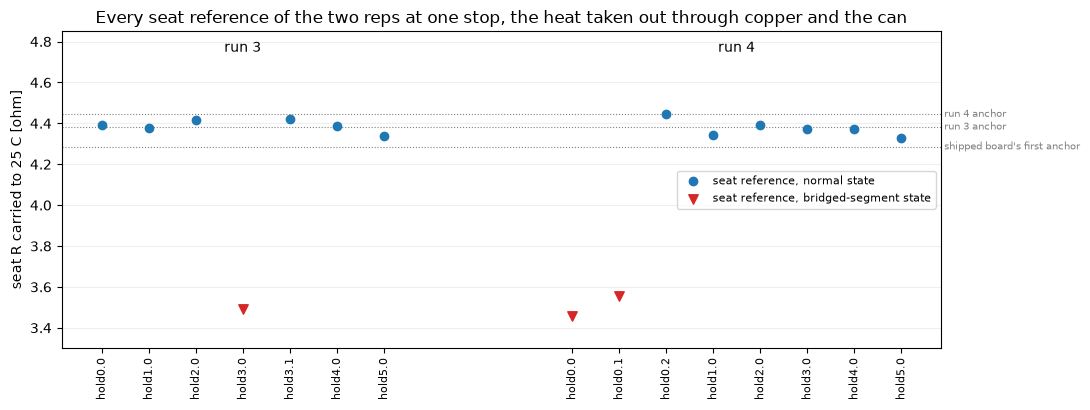

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ticks, labels = [], []
for j, (c, g) in enumerate(SEATS.groupby("capture")):
    x = np.arange(len(g)) + j * (len(g) + 2)
    ax.scatter(x[~g.low.to_numpy()], g.r25[~g.low] * OHM_Q12, color="tab:blue", s=36, zorder=3,
               label="seat reference, normal state" if j == 0 else None)
    ax.scatter(x[g.low.to_numpy()], g.r25[g.low] * OHM_Q12, color="tab:red", marker="v", s=46, zorder=3,
               label="seat reference, bridged-segment state" if j == 0 else None)
    ticks += list(x)
    labels += list(g.hold + "." + g.n.astype(str))
    ax.text(x.mean(), 4.75, "run 3" if c.endswith("1") else "run 4", ha="center")
for v, lab in ((anchors["oab/capture-1"], "run 3 anchor"), (anchors["oab/capture-2"], "run 4 anchor"),
               (anchors["the shipped board's first anchor"], "shipped board's first anchor")):
    ax.axhline(v * OHM_Q12, color="grey", lw=0.8, ls=":")
    ax.text(ax.get_xlim()[1], v * OHM_Q12, " " + lab, va="center", fontsize=7, color="grey")
ax.set_ylim(3.3, 4.85)
ax.set_xticks(ticks, labels, rotation=90, fontsize=8)
ax.set_ylabel("seat R carried to 25 C [ohm]")
ax.set_title("Every seat reference of the two reps at one stop, the heat taken out through copper and the can")
ax.legend(fontsize=8, loc="center right")
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

**What you are looking at.** The same references as a picture, in ohms, with the three anchors as
dotted lines. The blue dots are the normal state and scatter about a tenth of an ohm. The red
triangles are the bridged state, far under everything else.

## 2. The estimator as shipped

The thermometer steps at the kernel's SLOW rate, 62.5 Hz. Every step it takes the drive-window
terminal voltage $v$ (duty-weighted, in vcounts), the current $i$ (ccounts), the pot observer's
speed $\omega$ and the NTC, and does the following.

**The gate.** A sample counts when $|i|$ is over `rtherm_i_min_counts` and both $v$ and $i$ moved
less than an eighth of themselves for two ticks in a row. A shaft that turns fails the gate, so no
sample ever has back-EMF in it.

**The reference.** At a new seat it skips 62 gated ticks (1 s, the contact settling under current)
and then averages 128 more (2 s):

$$R_{ref} = \frac{\sum v}{\sum i} \qquad T_{ref} = \text{the carried temperature at that moment}$$

So a new seat never steps the reading. It inherits whatever the carry said.

**Tracking.** From then on a sign-data LMS (least-mean-squares) tracker follows $\hat R$, and copper
turns the ratio into a temperature:

$$\hat R \leftarrow \hat R + \mu \cdot \mathrm{sgn}(i) \cdot (v - \hat R i) \qquad
T = T_{ref} + (234.5 + T_{ref}) \left(\frac{\hat R}{R_{ref}} - 1\right)$$

**The carry.** Every tick, tracked or not, the excess $x$ over the NTC steps toward $g P$:

$$x \leftarrow x + \alpha (g P - x) \qquad P = \max(0, i (v - K_e \omega)) \qquad T = T_{NTC} + x$$

with $\alpha = \Delta t / \tau$. While tracking, the tracked $T$ overwrites $x$, so the carry always
leaves from the last thing the ratio said.

**The exits.** The reference is dropped, and the next seat re-bases on the carry, when the shaft
leaves a 2-count band, when $i$ moves by more than $i_{ref}/8$, when $v$ moves by more than
$v_{ref}/8$ at a held current, when the tracked $T$ rises more than $x_{max}/32$ within one second
(the rise check, which keeps the value from before the rise), or when 32 ticks pass with no gated
sample.

**The bound.** The excess never passes 1.5 times the steady excess the current limit holds the cold
winding at, at the NTC's temperature:

$$x_{max} = 1.5 \cdot I_{lim} \cdot V_{lim} \cdot g \qquad V_{lim} = \frac{r_0 (234.5 + T_{NTC})}{259.5} \cdot \frac{I_{lim}}{4096}$$

**The boot prior.** At boot $x = x_{max}/3$, half the steady excess at the limit, decaying on
$\tau$ unless power sustains it.

**The derate.** Between 80 and 100 C the current limit folds down in a straight line,
$I = I_{lim} (T_{cut} - T) / (T_{cut} - T_{derate})$, and at 100 C the cutoff latches.

The table fields that set all of this, as the board in this dataset carries them:

In [4]:
# The thermometer's table fields as the shipped board carries them: the first anchor's write
# (anchor-m1.out), then r0_q12 set by hand to run 4's normal-state anchor (r0-write.out).
F = tm.calib_fields((DS.path / "anchor-m1.out").read_text())
F.update(tm.calib_fields((DS.path / "r0-write.out").read_text()))
cfg_default = dict(seat_band_counts=2, cold_band_q016=1966)        # zero in the table reads as these (regions/config.rs)


def ntc_quad_c(raw, f=F):
    # the host's quadratic about the 25 C point, as the kernel evaluates it (estimator::thermal::ntc_cc)
    d = f["ntc_raw_ref"] - np.asarray(raw, float)
    return (f["ntc_t_ref_cc"] + d * f["ntc_k1_q88"] / 256 + d * d * f["ntc_k2_q24"] / 2 ** 24) / 100


tau_s = 2 ** 24 / (F["th_alpha_q24"] * tm.SLOW_HZ)
r_th = F["th_g_q016"] / 65536 / (W_UNIT * 100)
settle_s = 65536 / (F["th_mu_q016"] * 280 * tm.SLOW_HZ / 4096)     # the LMS time constant at the 280-count hold
rows = [
    ("th_alpha_q24", F["th_alpha_q24"], "carry step per SLOW tick, dt/tau, Q0.24", f"tau {tau_s:.1f} s at {tm.SLOW_HZ} Hz"),
    ("th_g_q016", F["th_g_q016"], "steady excess per unit of i(v - Ke w), centi-C, Q0.16", f"{r_th:.1f} C/W over the NTC"),
    ("th_mu_q016", F["th_mu_q016"], "LMS step on e = v - R i, Q0.16", f"{settle_s:.2f} s to settle at 280 counts"),
    ("r0_q12", F["r0_q12"], "cold winding R at 25 C, vcount/ccount, Q4.12", f"{F['r0_q12'] * OHM_Q12:.3f} ohm"),
    ("rtherm_i_min_counts", F["rtherm_i_min_counts"], "current floor for a sample", f"{F['rtherm_i_min_counts'] * board.a_per_count * 1e3:.0f} mA"),
    ("current_limit_counts", F["current_limit_counts"], "bounds the excess and sets the boot prior", f"{F['current_limit_counts'] * board.a_per_count * 1e3:.0f} mA"),
    ("ntc_raw_ref / ntc_t_ref_cc", f"{F['ntc_raw_ref']} / {F['ntc_t_ref_cc']}", "the NTC curve's 25 C point", f"{F['ntc_t_ref_cc'] / 100:.2f} C at {F['ntc_raw_ref']} counts"),
    ("ntc_k1_q88 / ntc_k2_q24", f"{F['ntc_k1_q88']} / {F['ntc_k2_q24']}", "slope and curvature about it", f"{F['ntc_k1_q88'] / 256:.3f} centi-C per count"),
    ("rtherm_seat_band_counts", "0 (default)", "a seat's position band", f"{cfg_default['seat_band_counts']} counts"),
    ("rtherm_cold_band_q016", "0 (default)", "cold-R recalibrate band", f"{cfg_default['cold_band_q016'] / 65536 * 100:.1f}% of r0"),
    ("derate_start_cc / recover_cc / cutoff_cc", f"{F['derate_start_cc']} / {F['recover_cc']} / {F['cutoff_cc']}", "the foldback and the latch",
     f"{F['derate_start_cc'] / 100:.0f} / {F['recover_cc'] / 100:.0f} / {F['cutoff_cc'] / 100:.0f} C"),
]
display(pd.DataFrame(rows, columns=["field", "raw", "what", "physical"]).set_index("field"))

raw = np.array([1500, 1700, 1900, 2048, 2300, 2600])
print("NTC quadratic against the beta model (10K / 10K / 3950), C: " +
      ", ".join(f"{r}: {ntc_quad_c(r):.2f} vs {th.ntc_c(r):.2f}" for r in raw))


def x_max_c(t_ntc_c, f=F, i_lim=None):
    # the excess bound: 1.5 x the steady excess the current limit holds the cold R at, at the NTC
    i_lim = f["current_limit_counts"] if i_lim is None else i_lim
    r_q12 = f["r0_q12"] * (K_CU + t_ntc_c) / (K_CU + 25)
    v = r_q12 * i_lim / 4096
    return 1.5 * i_lim * v * f["th_g_q016"] / 65536 / 100


print(f"at an NTC of 28 C: the bound x_max {x_max_c(28.0):.1f} C, the boot prior x_max / 3 {x_max_c(28.0) / 3:.2f} C, "
      f"the rise check x_max / 32 {x_max_c(28.0) / 32:.2f} C in 1 s, the power at the limit "
      f"{F['current_limit_counts'] ** 2 * F['r0_q12'] * (K_CU + 28) / (K_CU + 25) / 4096 * W_UNIT:.3f} W")

,raw,what,physical
field,,,
th_alpha_q24,2097,"carry step per SLOW tick, dt/tau, Q0.24",tau 128.0 s at 62.5 Hz
th_g_q016,1500,"steady excess per unit of i(v - Ke w), centi-C...",63.0 C/W over the NTC
th_mu_q016,8073,"LMS step on e = v - R i, Q0.16",1.90 s to settle at 280 counts
r0_q12,4078,"cold winding R at 25 C, vcount/ccount, Q4.12",4.446 ohm
rtherm_i_min_counts,232,current floor for a sample,209 mA
current_limit_counts,280,bounds the excess and sets the boot prior,253 mA
ntc_raw_ref / ntc_t_ref_cc,2048 / 2500,the NTC curve's 25 C point,25.00 C at 2048 counts
ntc_k1_q88 / ntc_k2_q24,563 / 5779,slope and curvature about it,2.199 centi-C per count
rtherm_seat_band_counts,0 (default),a seat's position band,2 counts


NTC quadratic against the beta model (10K / 10K / 3950), C: 1500: 38.09 vs 37.87, 1700: 33.07 vs 32.92, 1900: 28.33 vs 28.28, 2048: 25.00 vs 24.99, 2300: 19.68 vs 19.52, 2600: 13.91 vs 13.05
at an NTC of 28 C: the bound x_max 27.1 C, the boot prior x_max / 3 9.04 C, the rise check x_max / 32 0.85 C in 1 s, the power at the limit 0.287 W


**What you are looking at.** One row per field, its raw value, what it is, and what that means
physically through the board's 4.0283 mV and 0.9022 mA per count. Under it, the NTC quadratic
against the thermistor's beta model, then the bound, the boot prior and the rise check at a 28 C
NTC.

- **$\alpha$ 2097 is $\tau$ 128.0 s, and $g$ 1500 is 63.0 C/W over the NTC.** Those are the
  family constants. Section 6 is about what they mean.
- **$\mu$ 8073 settles the LMS in 1.90 s at the 280-count hold**, about the length of the
  reference window.
- **The NTC quadratic is within 0.22 C of the beta model from 19 to 38 C** and 0.86 C off at 13 C.
  The curve is not where any error in this notebook comes from.
- **At the 280-count limit and a 28 C NTC the bound is 27.1 C, the boot prior 9.04 C and the rise
  check 0.85 C in one second.** All three scale with $g$, which is why the family constant matters
  even though holds are read by the ratio.

## 3. The can-witness experiment

- **Procedure.** Reset the board, so the first hold is the first seat since boot. Log 660 s with
  torque off. Then `th oab`, the out-and-back rep, a 150 s hold at the low stop under the 280-count
  limit, then five more 60 s holds at the same stop, each after the shaft goes out toward mid
  travel and comes back, with torque off for 240, 30, 240, 30 and 240 s before the seek back. Then
  300 s more with torque off. `th` polls the telemetry span every 6.6 ms through all of it, and the
  thermocouple on the can sends a packet every 0.51 s.
- **Model.** After long enough with torque off, the winding, the can and the board sit at one
  temperature, and the can minus the NTC there is the **rest offset**. The truth for the
  NTC-based thermometer is then $T^{\ast} = T_{can} - (T_{can} - T_{NTC})_{rest}$. The winding
  trails the can by tens of seconds (notebook 18), so after a 240 s gap it sits within a few tenths
  of the can, and $T^{\ast}$ is the truth at the next seat. After a 30 s gap it is not.
- **Estimator.** The carried temperature the new hold's first base inherits. That is the carry's
  whole account of the gap, with no resistance in it.
- **Validity envelope.** One stop, the 280-count limit, gaps of 30 and 240 s, the can a few
  degrees over room, free air on the bench with the board beside the servo.
- **Accuracy.** Graded against the can bead only. The bead itself is not graded against anything.

The rest offset is the median of the can minus the median of the NTC over the last 180 s of each
rest, the same window for both. Four rests have one, the two reps' and the rests before the two
thermal holds of section 6.

In [5]:
rows = []
for c, r in REST.items():
    rows.append({"rest": c, "can C": r["can"], "can sd": r["can_sd"], "packets": r["n"], "board NTC C": r["ntc"],
                 "t_winding C": r["t_w"], "rest offset can - NTC C": r["offset"]})
display(pd.DataFrame(rows).set_index("rest").round(3))

GAPS = {}
for c, log in OAB.items():
    g = tm.gaps(log, MET[c], REST[c]["offset"], "first")
    GAPS[c] = g
    print(f"{c} ({'run 3' if c.endswith('1') else 'run 4'}), every gap to the new hold's first base:")
    display(g[["gap", "gap_s", "r_old", "r_new", "t_ntc", "can", "t_star", "carried", "carry_m_t", "ratio", "ratio_m_t", "step"]]
            .rename(columns={"carry_m_t": "carried - T*", "ratio": "same-seat ratio", "ratio_m_t": "ratio - T*", "step": "step at base"})
            .set_index("gap").round(2))
last = tm.gaps(OAB["oab/capture-1"], MET["oab/capture-1"], REST["oab/capture-1"]["offset"], "last")
print(f"run 3 gap 3 to hold3's LAST base instead (run 3's scorer): carried {last.carried[2]:.2f}, T* {last.t_star[2]:.2f}, "
      f"carried - T* {last.carry_m_t[2]:+.2f} C")

,can C,can sd,packets,board NTC C,t_winding C,rest offset can - NTC C
rest,,,,,,
oab/capture-1,27.2,0.046,360,29.95,29.950,-2.75
oab/capture-2,26.2,0.074,360,28.23,28.230,-2.03
thermal/capture-1,25.6,0.043,360,28.25,28.250,-2.65
thermal/capture-2,25.3,0.022,360,27.93,27.955,-2.63


oab/capture-1 (run 3), every gap to the new hold's first base:


,gap_s,r_old,r_new,t_ntc,can,t_star,carried,carried - T*,same-seat ratio,ratio - T*,step at base
gap,,,,,,,,,,,
1,240,4107,4109,30.11,28.2,30.95,32.09,1.14,30.51,-0.44,0.00
2,30,4109,4181,30.28,30.5,33.25,36.81,3.56,36.76,3.51,0.00
3,240,4181,3279,30.16,28.3,31.05,31.85,0.80,-21.72,-52.77,0.00
4,30,3279,4146,30.38,30.2,32.95,70.62,37.67,102.28,69.33,-0.01
5,240,4146,4070,30.23,28.3,31.05,37.33,6.28,65.03,33.98,0.00


oab/capture-2 (run 4), every gap to the new hold's first base:


,gap_s,r_old,r_new,t_ntc,can,t_star,carried,carried - T*,same-seat ratio,ratio - T*,step at base
gap,,,,,,,,,,,
1,240,3209,4042,28.18,26.8,28.83,28.88,0.05,96.73,67.90,0.0
2,30,4042,4121,28.39,29.0,31.03,34.09,3.06,34.03,3.00,0.0
3,240,4121,4068,28.13,26.7,28.73,30.09,1.36,30.64,1.91,0.0
4,30,4068,4106,28.53,29.0,31.03,36.33,5.30,32.56,1.53,0.0
5,240,4106,4030,28.69,26.8,28.83,30.95,2.12,31.32,2.49,0.0


run 3 gap 3 to hold3's LAST base instead (run 3's scorer): carried 80.34, T* 31.45, carried - T* +48.89 C


**What you are looking at.** The four rest offsets, then one row per gap of each rep. The seat R on
either side of the gap, the NTC, the can, $T^{\ast}$, the carried temperature, and the carried
minus $T^{\ast}$. The same-seat ratio across the gap is there too, for comparison. It is the
reading a thermometer would give if it trusted a resistance from one seat at the next.

- **The NTC rests 2.03 to 2.75 C over the can.** The four rests read -2.75, -2.03, -2.65 and
  -2.63 C. That is the base's own error, and it moves by 0.7 C between rests on the same day.
- **Run 4 carries the 240 s gaps to +0.05, +1.36 and +2.12 C.** Always high, and higher each gap.
  The pre-registered pass was within 1.5 C at all three, so the third gap failed it.
- **The 30 s gaps read +3.06 and +5.30 C.** The winding is still warmer than the can there, so
  part of that is real. The pre-registered band was $T^{\ast}$ - 1 to $T^{\ast}$ + 8, and both sit
  inside it.
- **Run 3's one clean 240 s gap reads +1.14 C**, with the same-seat ratio at -0.44 C. Its third
  hold started in the bridged state (section 4), and everything after carries the false 80 C that
  produced. Run 3's own scorer took each hold's last base and so put gap 3 at +48.89 C. Here every
  gap uses the first base, the rule run 4's scorer used, and gap 3 reads +0.80 C, the base taken
  before the step.
- **The ratio across a gap is no better than the carry.** In run 4 it reads +3.00, +1.91, +1.53
  and +2.49 C over $T^{\ast}$, and it has a seat-to-seat contact change in it that no heat made.

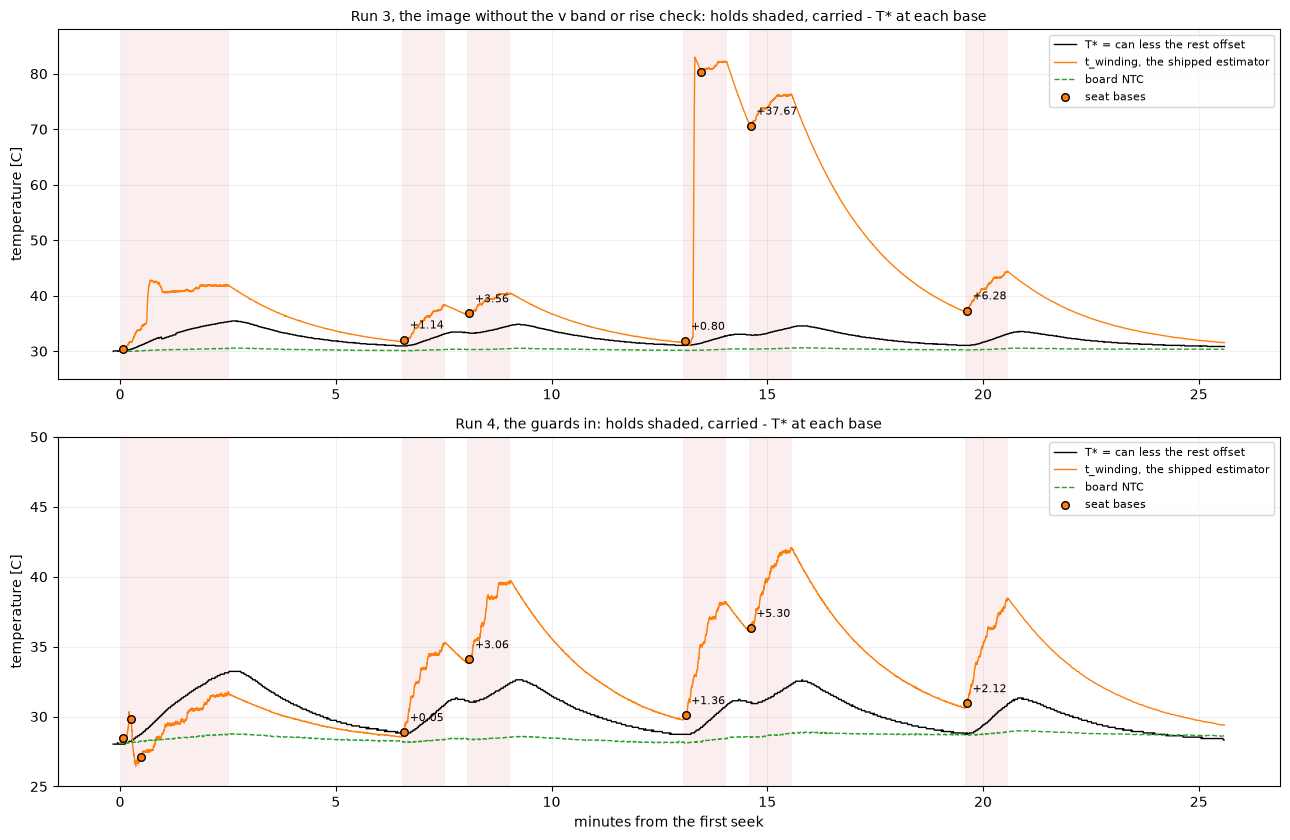

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8.5), sharex=False)
for ax, (c, log) in zip(axes, OAB.items()):
    post = tm.th_log(DS, c, "post")
    full = pd.concat([log, post], ignore_index=True)
    t0 = log.t_unix.iloc[0]
    m = MET[c][(MET[c].t_unix >= t0 - 10) & (MET[c].t_unix <= full.t_unix.max())]
    ax.plot((m.t_unix - t0) / 60, m.can_c - REST[c]["offset"], color="k", lw=1, label="T* = can less the rest offset")
    ax.plot((full.t_unix - t0) / 60, full.t_w, color="tab:orange", lw=1, label="t_winding, the shipped estimator")
    ax.plot((full.t_unix - t0) / 60, full.t_ntc, color="tab:green", lw=1, ls="--", label="board NTC")
    for p in tm.holds(log):
        g = log[log.phase == p]
        ax.axvspan((g.t_unix.iloc[0] - t0) / 60, (g.t_unix.iloc[-1] - t0) / 60, color="tab:red", alpha=0.08, lw=0)
    b = tm.bases(log)
    ax.scatter((b.t_unix - t0) / 60, b.t_w, s=30, color="tab:orange", edgecolor="k", zorder=4, label="seat bases")
    g = GAPS[c]
    for x in g.itertuples():
        ax.annotate(f"{x.carry_m_t:+.2f}", ((x.t_unix - t0) / 60, x.carried), xytext=(4, 8), textcoords="offset points", fontsize=8)
    ax.set_ylim(25, 88 if c.endswith("1") else 50)
    ax.set_ylabel("temperature [C]")
    ax.set_title(f"{'Run 3, the image without the v band or rise check' if c.endswith('1') else 'Run 4, the guards in'}: "
                 "holds shaded, carried - T* at each base", fontsize=10)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("minutes from the first seek")
plt.tight_layout()
plt.show()

**What you are looking at.** Each rep from the first seek to the end of the torque-off log after
it. The black line is $T^{\ast}$, the orange the firmware's `t_winding`, the green dashes the NTC,
holds shaded red, and the orange dots the bases with carried minus $T^{\ast}$ written beside them.

Inside a hold the reading climbs well over the can. That is the winding heating at 0.29 W while
the can lags it, which is what the thermometer is for. Off torque the carry decays toward the NTC on
128 s and lands a degree or two over $T^{\ast}$ at the next seat. In run 3 the third hold's reading
shoots to 83 C, and the carry takes the rest of the rep to come back down.

## 4. The bridging event, and what the guards do

Run 3's third hold seated with the circuit about 20% low and based there. The firmware read the
seat correctly, the circuit really was that low. Then partway through the hold the circuit stepped
back to normal at the same seat. The current fell at constant duty, and the duty limiter answered
by raising the duty a quarter. The image run 3 ran had only the position and current exits, so the
reference stayed and the ratio read the step as heat. The analysis behind the guards is in the
bringup notes. Here are the ticks.

In [7]:
log = OAB["oab/capture-1"]
h = log[log.phase == "hold3"].copy()
h["t"] = h.t_unix - h.t_unix.iloc[0]
h["r_ohm"] = h.r_hat_q12 * OHM_Q12
b3 = tm.bases(log).query("hold == 'hold3'")
# the step back: the first poll after the base where the current falls 5 counts under its running median at constant duty
based = h[h.t > b3.t_s.iloc[0]]
med = based.i.rolling(40, min_periods=10).median().shift(1)
step = based[(based.i < med - 5) & (based.duty_applied_q15 == based.duty_applied_q15.iloc[0])].iloc[0]
duty_up = based[based.duty_applied_q15 != based.duty_applied_q15.iloc[0]].iloc[0]
pk = h.loc[h.t_w.idxmax()]
normal = SEATS[(SEATS.capture == "oab/capture-1") & ~SEATS.low].r_hat.median()
print(f"hold3 base at +{b3.t_s.iloc[0]:.2f} s on R {b3.r_hat.iloc[0]} ({b3.r_hat.iloc[0] * OHM_Q12:.2f} ohm), "
      f"{(b3.r_hat.iloc[0] / normal - 1) * 100:+.1f}% against the run's normal seats ({normal:.0f}); duty {abs(b3.duty.iloc[0]) / 327.67:.1f}% at {b3.i.iloc[0]} counts")
print(f"the current steps down at +{step.t:.2f} s ({step.i} counts at duty {abs(step.duty_applied_q15) / 327.67:.1f}%), "
      f"the duty limiter answers at +{duty_up.t:.2f} s: {abs(based.duty_applied_q15.iloc[0])} -> {abs(duty_up.duty_applied_q15)} "
      f"({(abs(duty_up.duty_applied_q15) / abs(based.duty_applied_q15.iloc[0]) - 1) * 100:+.1f}% of v at the held current)")
print(f"t_winding peaks at {pk.t_w:.2f} C at +{pk.t:.2f} s with T* {tm.can_at(MET['oab/capture-1'], pk.t_unix) - REST['oab/capture-1']['offset']:.2f} C; "
      f"i_lim falls to {h.i_lim.min()}")
x = h.loc[h.i_lim.idxmin()]
print(f"derate check at the lowest i_lim: 280 x (100 - {x.t_w:.2f}) / (100 - 80) = {280 * (100 - x.t_w) / 20:.1f} against {x.i_lim} logged")
# the rise per second while tracking, every hold of both runs: the rise check's evidence
rows = []
for c, lg in OAB.items():
    for p in tm.holds(lg):
        g = lg[(lg.phase == p) & lg.track]
        if len(g) < 50:
            continue
        tu, tw = g.t_unix.to_numpy(), g.t_w.to_numpy()
        k = np.searchsorted(tu, tu - 1.0)                     # the row one second earlier
        ok = tu - tu[k] > 0.9                                  # inside one tracked stretch
        r1 = pd.Series((tw - tw[k])[ok])
        rows.append({"run": "run 3" if c.endswith("1") else "run 4", "hold": p, "max rise in 1 s, C": r1.max()})
RISE = pd.DataFrame(rows).set_index(["run", "hold"])
display(RISE.round(2).T)
print(f"at hold3's NTC ({b3.t_ntc.iloc[0]:.2f} C) and run 3's anchor, the shipped rules would give: rise check "
      f"{x_max_c(b3.t_ntc.iloc[0], dict(F, r0_q12=anchors['oab/capture-1'])) / 32:.2f} C in 1 s, bound NTC + "
      f"{x_max_c(b3.t_ntc.iloc[0], dict(F, r0_q12=anchors['oab/capture-1'])):.1f} C = "
      f"{b3.t_ntc.iloc[0] + x_max_c(b3.t_ntc.iloc[0], dict(F, r0_q12=anchors['oab/capture-1'])):.1f} C, under the {F['derate_start_cc'] / 100:.0f} C derate")

hold3 base at +2.72 s on R 3279 (3.57 ohm), -20.6% against the run's normal seats (4128); duty 12.6% at 268 counts
the current steps down at +13.42 s (260 counts at duty 12.6%), the duty limiter answers at +13.48 s: 4129 -> 5153 (+24.8% of v at the held current)
t_winding peaks at 83.01 C at +15.96 s with T* 31.25 C; i_lim falls to 237
derate check at the lowest i_lim: 280 x (100 - 83.01) / (100 - 80) = 237.9 against 237 logged


run                run 3                                run 4              \
hold               hold0 hold1 hold2  hold3 hold4 hold5 hold0 hold1 hold2   
max rise in 1 s, C  3.61  0.52  0.46  27.94  0.74  0.54  1.07  0.65  0.72   

run                                   
hold               hold3 hold4 hold5  
max rise in 1 s, C  0.78  0.47  0.53

at hold3's NTC (30.16 C) and run 3's anchor, the shipped rules would give: rise check 0.84 C in 1 s, bound NTC + 26.9 C = 57.1 C, under the 80 C derate


**What you are looking at.** The hold3 timeline from the tick log, the derate's arithmetic, then the
largest rise of the tracked temperature within one second in every hold of both reps, and what
the shipped guards would allow at hold3's NTC.

- **The base came at +2.72 s on 3.57 ohm, -20.6% against the run's normal seats.** The duty was
  12.6% at 268 counts, where the normal seats ran at duty 5025 to 5153 (raw Q15).
- **At +13.42 s the current stepped down at the same duty, and at +13.48 s the limiter raised the
  duty from 4129 to 5153, +24.8% of $v$ at the held current.** With no voltage band the reference
  stayed, and the LMS walked $\hat R$ up at its own rate. The reading went to 83.01 C at +15.96 s
  with $T^{\ast}$ at 31.25 C.
- **The derate did exactly what it was told.** At 83.01 C it gives 237.9 counts, and the log shows
  237. The current-band exit then froze the false reading into the carry, which is how gaps 4 and 5
  inherited it.
- **No heating here rises faster than about 1 C in one second.** The other holds' largest
  one-second rises are 0.46 to 1.07 C. Run 3's first hold rose 3.61 C in a second (a smaller contact
  step) and hold3 27.94 C.
- **The shipped rules at hold3's NTC.** The rise check trips at 0.84 C in one second, and the bound
  holds the reading under NTC + 26.9 C, 57.1 C, under the 80 C derate. Either alone would have kept
  the derate out of it, and the voltage band catches the step itself.

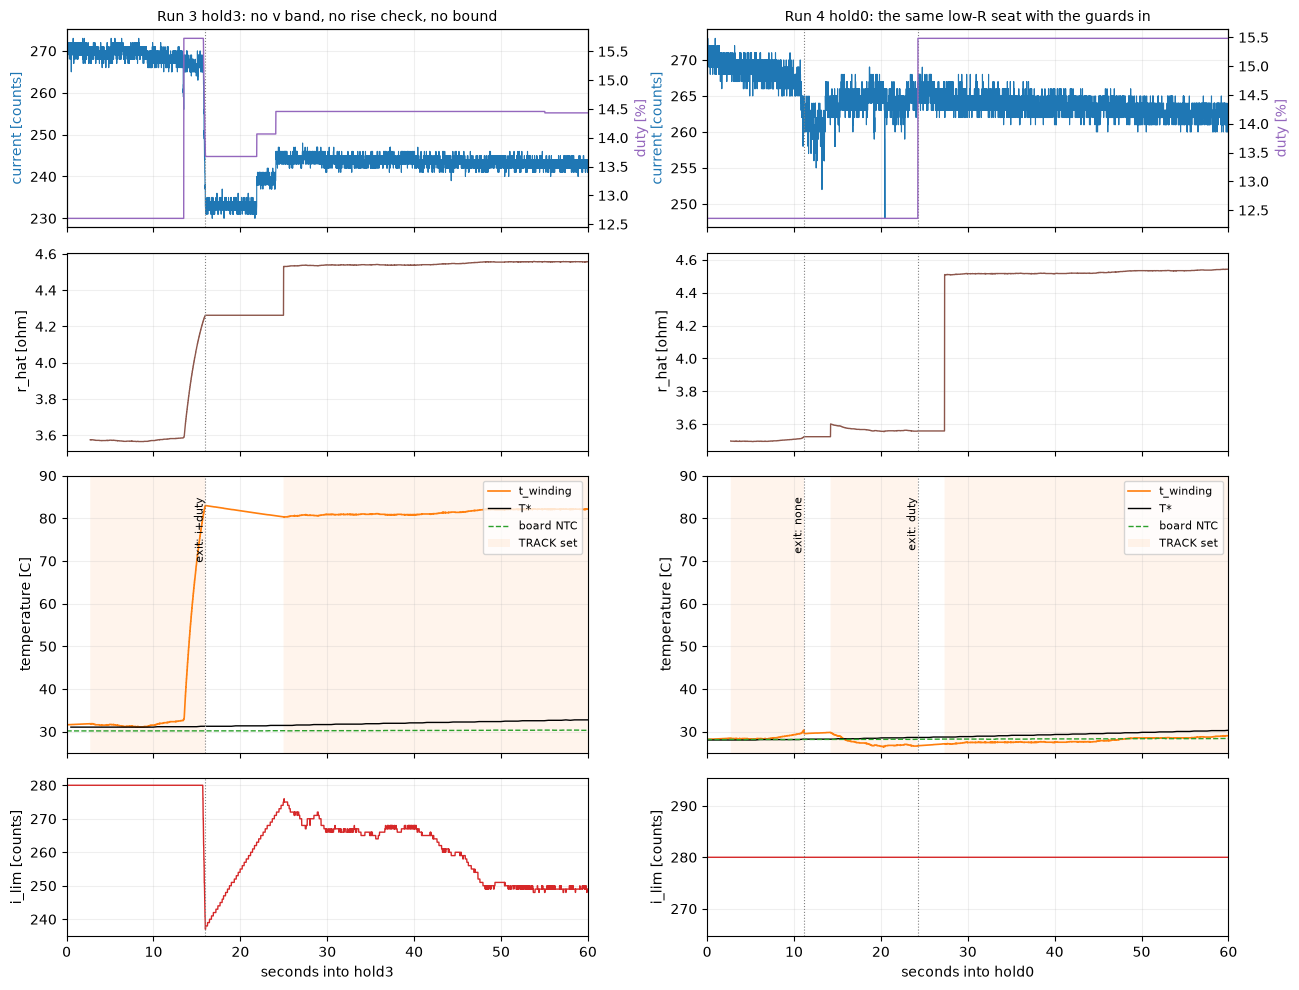

moved  i_before  i_after  i_ref  duty_before  duty_after  \
hold  t_s                                                              
hold0 11.16  none    261.67   262.77  269.4        -4049       -4049   
      24.27  duty    264.83   265.62  263.8        -4049       -5073   

             t_w_before  t_w_next_base  T* at the exit  t_w - T* before  \
hold  t_s                                                                 
hold0 11.16       30.35          29.81           28.23             2.12   
      24.27       26.69          27.14           28.63            -1.94   

             carried change  
hold  t_s                    
hold0 11.16           -0.54  
      24.27            0.45

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(13, 10), sharex="col", gridspec_kw=dict(height_ratios=[1, 1, 1.4, 0.8]))
for j, (c, p) in enumerate((("oab/capture-1", "hold3"), ("oab/capture-2", "hold0"))):
    lg = OAB[c]
    g = lg[lg.phase == p].copy()
    t0 = g.t_unix.iloc[0]
    g["t"] = g.t_unix - t0
    a0, a1, a2, a3 = axes[:, j]
    a0.plot(g.t, g.i, color="tab:blue", lw=0.8, label="current over the zero [counts]")
    a0b = a0.twinx()
    a0b.plot(g.t, g.duty_applied_q15.abs() / 327.67, color="tab:purple", lw=1, label="applied duty [%]")
    a0b.set_ylabel("duty [%]", color="tab:purple")
    a0.set_ylabel("current [counts]", color="tab:blue")
    first = tm.bases(lg).query("hold == @p").t_s.iloc[0]
    r = (g.r_hat_q12 * OHM_Q12).where(g.t >= first)             # before the first base r_hat is the last hold's
    a1.plot(g.t, r, color="tab:brown", lw=1)
    a1.set_ylabel("r_hat [ohm]")
    m = MET[c][(MET[c].t_unix >= t0) & (MET[c].t_unix <= g.t_unix.max())]
    a2.plot(g.t, g.t_w, color="tab:orange", lw=1.2, label="t_winding")
    a2.plot(m.t_unix - t0, m.can_c - REST[c]["offset"], color="k", lw=1, label="T*")
    a2.plot(g.t, g.t_ntc, color="tab:green", lw=1, ls="--", label="board NTC")
    a2.fill_between(g.t, 20, 100, where=g.track, color="tab:orange", alpha=0.08, lw=0, label="TRACK set")
    a2.set_ylim(25, 90)
    a2.set_ylabel("temperature [C]")
    a2.legend(fontsize=8, loc="upper right")
    a3.plot(g.t, g.i_lim, color="tab:red", lw=1)
    a3.set_ylabel("i_lim [counts]")
    a3.set_xlabel(f"seconds into {p}")
    a3.set_xlim(0, 60)
    for e in tm.exits(lg).query("hold == @p").itertuples():
        for a in (a0, a1, a2, a3):
            a.axvline(e.t_s, color="grey", lw=0.8, ls=":")
        a2.annotate(f"exit: {e.moved}", (e.t_s, 85), fontsize=8, rotation=90, va="top", ha="right")
    a0.set_title("Run 3 hold3: no v band, no rise check, no bound" if j == 0 else "Run 4 hold0: the same low-R seat with the guards in",
                 fontsize=10)
    for a in (a0, a1, a2, a3):
        a.grid(alpha=0.2)
plt.tight_layout()
plt.show()
EX4 = tm.exits(OAB["oab/capture-2"])
EX4["T* at the exit"] = tm.can_at(MET["oab/capture-2"], EX4.t_unix.to_numpy()) - REST["oab/capture-2"]["offset"]
EX4["t_w - T* before"] = EX4.t_w_before - EX4["T* at the exit"]
EX4["carried change"] = EX4.t_w_next_base - EX4.t_w_before
display(EX4.drop(columns="t_unix").round(2).set_index(["hold", "t_s"]))

**What you are looking at.** Left, run 3's hold3, right, run 4's first hold, which also seated in
the low state, both over their first minute. Top to bottom, the current and the duty, $\hat R$ in
ohms from the first base on, the reading against $T^{\ast}$ and the NTC with the tracked stretches
shaded, and the current limit. The dotted lines are the exits, with the table of run 4's under the
plot.

On the right the low seat based at +2.72 s like hold3 did. At +11.16 s it was dropped with nothing
moved, which is the rise check by elimination, and at +24.27 s the duty stepped from 4049 to 5073
and the voltage band dropped it. The carried reading moved -0.54 and +0.45 C across the two exits,
and the limit stayed at 280. What the guards do not catch is the second low base's own drift. Its
$\hat R$ fell while the circuit sat low, and the reading went 1.94 C under $T^{\ast}$ before the
duty step ended it.

## 5. The boot prior

After a reset the NTC reads the board, which cools in minutes, and the winding could be anywhere.
No resistance can say how hot it is, because there is no seat yet, and section 1 says a stored R is
no good anyway. The image before the shipped one tried. On the first seat after boot it compared
the reference with the stored cold R and, past a band of a few percent, read the difference as
heat. The shipped image drops that and starts the carry at a prior instead, $x_{max}/3$, decaying on
$\tau$.

Two boot logs run the shipped image, one reset two minutes after a 480 s hold and one power-on
after the servo sat off for most of an hour. Both log from the reset with torque off and nothing
driven. Then the two first seats that sank the retired rule.

the reset came 129 s after the 480 s hold's last poll; the power-on 53 min after that log ended
reset 129 s after a 480 s hold: first row 0.00 s after the reset, therm_flags seen [np.int64(0)], NTC 28.88 C, can 28.90 C
power-on after 53 min off: first row 20.74 s after the reset, therm_flags seen [np.int64(0)], NTC 26.57 C, can 25.20 C


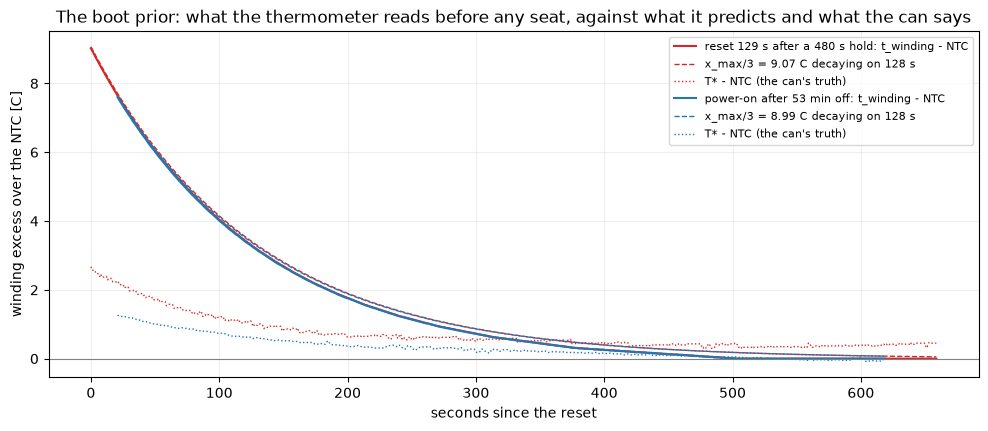

s since reset  \
boot                           s after the first row                  
reset 129 s after a 480 s hold 0                               0.00   
                               10                             10.07   
                               60                             60.39   
                               120                           120.27   
                               240                           240.47   
                               360                           360.24   
                               600                           600.39   
power-on after 53 min off      0                              20.74   
                               10                             32.74   
                               60                             82.70   
                               120                           142.69   
                               240                           262.64   
                               360                           382.62   
                               600                           618.56   

                                                      t_winding - NTC  \
boot                           s after the first row                    
reset 129 s after a 480 s hold 0                                 9.02   
                               10                                8.33   
                               60                                5.57   
                               120                               3.43   
                               240                               1.24   
                               360                               0.40   
                               600                               0.00   
power-on after 53 min off      0                                 7.60   
                               10                                6.90   
                               60                                4.62   
                               120                               2.83   
                               240                               1.02   
                               360                               0.30   
                               600                               0.00   

                                                      prior predicts  \
boot                           s after the first row                   
reset 129 s after a 480 s hold 0                                9.07   
                               10                               8.38   
                               60                               5.66   
                               120                              3.54   
                               240                              1.39   
                               360                              0.54   
                               600                              0.08   
power-on after 53 min off      0                                7.64   
                               10                               6.96   
                               60                               4.71   
                               120                              2.95   
                               240                              1.15   
                               360                              0.45   
                               600                              0.07   

                                                      T* - NTC  reading - T*  
boot                           s after the first row                          
reset 129 s after a 480 s hold 0                          2.67          6.35  
                               10                         2.37          5.96  
                               60                         1.56          4.01  
                               120                        1.07          2.36  
                               240                        0.70          0.54  
                               360        

,image,seat,r_hat at base,over r0 3932 %,t_winding before C,after C,step C,T* C,flags at base
capture,,,,,,,,,
firstseat/capture-1,26f38948,219,4283,8.93,29.23,48.15,18.92,28.75,10
firstseat/capture-2,bb9b0ceb,218,4305,9.49,28.77,49.60,20.83,30.05,10


In [9]:
rows = []
fig, ax = plt.subplots(figsize=(12, 4.5))
after_hold = BOOT["boot/capture-1"].t_unix.iloc[0] - RUN["thermal/capture-1"][1].t_unix.max()
after_off = BOOT["boot/capture-2"].t_unix.iloc[0] - BOOT["boot/capture-1"].t_unix.iloc[-1]
print(f"the reset came {after_hold:.0f} s after the 480 s hold's last poll; the power-on {after_off / 60:.0f} min after that log ended")
BOOTACC = []
for c, color, label in (("boot/capture-1", "tab:red", f"reset {after_hold:.0f} s after a 480 s hold"),
                        ("boot/capture-2", "tab:blue", f"power-on after {after_off / 60:.0f} min off")):
    b = BOOT[c]
    m = MET[c]
    b = b.assign(t=b.sample_tick / 20000)                    # s since the reset: the tick counter starts at 0, 20 kHz
    x = b.t_w - b.t_ntc
    # the prior: x_max / 3 at the NTC of the first conversion, decaying on tau with no power
    x0 = x_max_c(b.t_ntc.iloc[0]) / 3
    pred = x0 * np.exp(-b.t / tau_s)
    # the truth the can gives: T* less the NTC, with this session's rest offset (the rest before the next hold)
    off = REST["thermal/capture-1" if c.endswith("1") else "thermal/capture-2"]["offset"]
    truth = tm.can_at(m, b.t_unix.to_numpy()) - off - b.t_ntc
    ax.plot(b.t, x, color=color, lw=1.5, label=f"{label}: t_winding - NTC")
    ax.plot(b.t, pred, color=color, lw=1, ls="--", label=f"x_max/3 = {x0:.2f} C decaying on {tau_s:.0f} s")
    ax.plot(b.t, truth, color=color, lw=1, ls=":", label="T* - NTC (the can's truth)")
    for q in (0, 10, 60, 120, 240, 360, 600):
        k = min(np.searchsorted(b.t, b.t.iloc[0] + q), len(b) - 1)
        rows.append({"boot": label, "s after the first row": q, "s since reset": b.t.iloc[k], "t_winding - NTC": x.iloc[k],
                     "prior predicts": pred.iloc[k], "T* - NTC": truth[k], "reading - T*": x.iloc[k] - truth[k]})
    BOOTACC.append(x.iloc[0] - truth[0])
    print(f"{label}: first row {b.t.iloc[0]:.2f} s after the reset, therm_flags seen {sorted(b.therm_flags.unique())}, "
          f"NTC {b.t_ntc.iloc[0]:.2f} C, can {tm.can_at(m, b.t_unix.iloc[0], w=3):.2f} C")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("seconds since the reset")
ax.set_ylabel("winding excess over the NTC [C]")
ax.set_title("The boot prior: what the thermometer reads before any seat, against what it predicts and what the can says")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.show()
BOOTACC = np.array(BOOTACC)
display(pd.DataFrame(rows).set_index(["boot", "s after the first row"]).round(2))

# the retired rule's two first seats: a reference 9% over the stored cold R stepped the reading
rows = []
for c, lg in SEAT.items():
    b = tm.bases(lg).iloc[0]
    off = REST["thermal/capture-1"]["offset"]
    rows.append({"capture": c, "image": IX.loc[c, "image"], "seat": b.seat, "r_hat at base": b.r_hat,
                 "over r0 3932 %": (b.r_hat / 3932 - 1) * 100, "t_winding before C": b.t_w - b.step, "after C": b.t_w, "step C": b.step,
                 "T* C": tm.can_at(MET[c], b.t_unix) - off, "flags at base": int(lg.therm_flags[b.idx])})
display(pd.DataFrame(rows).set_index("capture").round(2))

**What you are looking at.** Each boot's reading over the NTC (solid), the prior's prediction from
the table constants and the NTC at the first conversion (dashed), and $T^{\ast}$ less the NTC, the
can's account of the true excess (dotted). The table samples the three at a few times. The last
table is the two first seats on the older images.

- **The prior is what the code says.** 9.02 C at the warm reset against 9.07 predicted, 7.60 C at
  the first logged row of the power-on (20.74 s in) against 7.64, and both decay on 128 s to 0.00
  by 600 s. The flags never left 0.
- **It reads high both times by the same amount.** The can says the winding was 2.67 C over the
  NTC two minutes after the hold and 1.26 C after the long rest. So the reading starts 6.35 and
  6.34 C over the truth, is within 0.54 and 0.68 C by 240 s, and settles a few tenths under it,
  -0.39 and -0.05 C, where the base offset of section 3 shows through. A warm reset this soon after
  a quarter-watt hold just is not very warm.
- **The retired rule stepped the reading 19 to 21 C.** Both first seats sat 8.93 and 9.49% over the
  stored cold R, with the stop reading 218 to 219 against the reps' 263 to 264. The rule read that as heat, so
  `t_winding` jumped from 29.23 to 48.15 C and from 28.77 to 49.60 C with $T^{\ast}$ at 28.75 and
  30.05 C. The shipped image takes such a seat at the carried value and does not step
  (`a_nine_percent_first_seat_moves_the_reading_under_half_a_degree`).

## 6. The family constants

The table carries $\tau$ 128 s and $g$ 63 C/W over the NTC for every MG90 on this board in open air.
They came from notebook 18's two-node model. Section 2 says they set the carry, the bound, the boot
prior and the rise check, so it is worth knowing what they are.

Two `osc ident thermal` runs give the data. Each seeks the low stop and holds it at the 280-count
limit for 480 s, with the can bead logging, and fits the kernel's excess over the NTC against the
power it put in. The first ran the free two-parameter fit, the second a newer tool that fits $g$
with $\tau$ tied to it. Neither tool is on main at this notebook's base.

First the can, which needs no thermometer at all. Its rise over the hold, carried to where it
would settle on notebook 18's slow mode, over the hold's mean power, is the can's resistance to
the air.

In [10]:
# nb18's anchored two-node fit (notebook 18 sec 4, "anchored room, all data"), the upstream of the
# shipped constants: winding 1.30 J/C over 28.0 C/W to a 2.22 J/C can over 31.97 C/W to the air.
NB18 = dict(c_w=1.30, c_c=2.22, r_wc=28.0, r_ca=31.97)
net18 = th.TwoNode(NB18["c_w"], NB18["c_c"], NB18["r_wc"], NB18["r_ca"])
fast, slow = net18.modes()
print(f"notebook 18's anchored network: modes {fast:.1f} s and {slow:.1f} s; winding over air {NB18['r_wc'] + NB18['r_ca']:.1f} C/W; "
      f"the shipped table: tau {tau_s:.1f} s, {r_th:.1f} C/W")

HOLD = {}
rows = []
for c in RUN:
    t, s, w = RUN[c]
    m = MET[c]
    h = s[(s.mode_active == 0) & (s.duty_applied_q15 < 0) & (s.pos < 400)]       # the seated hold's polls
    ts, te = h.t_unix.min(), h.t_unix.max()
    c0 = m[(m.t_unix > ts - 30) & (m.t_unix < ts)].can_c.median()               # the can just before the hold
    c1 = tm.can_at(m, te)
    p_w = t.p.mean() * W_UNIT                                                    # the hold's mean kernel power
    settled = (c1 - c0) / (1 - np.exp(-(te - ts) / slow))                        # the rise the can would settle at
    if "t_ntc_cc" in s:
        ntc = h.t_ntc_cc / 100
    else:                                                                        # the older osc logged x, not the NTC
        xx = pd.merge_asof(h[["t_unix", "t_winding_cc"]].sort_values("t_unix"), t[["t_unix", "x_cc"]].sort_values("t_unix"),
                           on="t_unix", direction="nearest")
        ntc = (xx.t_winding_cc - xx.x_cc) / 100
    d_ntc = ntc.iloc[-200:].median() - ntc.iloc[:200].median()
    HOLD[c] = dict(ts=ts, te=te, c0=c0, c1=c1, p_w=p_w, settled=settled, d_ntc=d_ntc,
                   ntc=pd.Series(ntc.to_numpy(), index=h.t_unix.to_numpy()))
    end = h.iloc[-1]
    rows.append({"hold": c, "image": IX.loc[c, "image"], "s": te - ts, "seat pos": f"{h.pos.min()}..{h.pos.max()}",
                 "i counts": h.i.median(), "P W": p_w, "can before C": c0, "can at end C": c1, "can rise C": c1 - c0,
                 "settled rise C": settled, "can over air C/W": settled / p_w, "NTC rise C": d_ntc,
                 "carried t_w at end C": end.t_winding_cc / 100, "T* at end C": c1 - REST[c]["offset"],
                 "carried - T* C": end.t_winding_cc / 100 - (c1 - REST[c]["offset"])})
FAM = pd.DataFrame(rows).set_index("hold")
display(FAM.round(3).T)

notebook 18's anchored network: modes 20.0 s and 128.9 s; winding over air 60.0 C/W; the shipped table: tau 128.0 s, 63.0 C/W


hold,thermal/capture-1,thermal/capture-2
image,bb9b0ceb,b4c4775b
s,480.439,480.448
seat pos,217..355,217..390
i counts,265.0,261.0
P W,0.269,0.26
can before C,25.6,25.4
can at end C,33.7,33.6
can rise C,8.1,8.2
settled rise C,8.3,8.402
can over air C/W,30.89,32.377


**What you are looking at.** Notebook 18's network and its modes, then one column per hold. The
hold's length, seat, current and mean power, the can before and at the end, the rise and the
settled rise, the can over the air per watt, the NTC's own rise, and the shipped thermometer's
reading at the end against $T^{\ast}$.

- **The can sits 30.89 and 32.38 C/W over the air.** Notebook 18's two blocks gave 32.0, and its
  network's slow mode is 128.9 s, which is the 128 s in the table. So $\tau$ is the can's slow
  mode, and the bench agrees with it.
- **63 C/W is notebook 18's winding over the air**, $R_{wc} + R_{ca}$, 60.0 C/W in its anchored fit
  with 60 to 77 across its variations. The carry is an excess over the NTC, and the NTC moved 1.16
  and 1.25 C during the holds, so for the carry to be right $g$ has to be the can's ~31 plus
  whatever the winding holds over the can, less the NTC's own rise.
- **The shipped thermometer read the first hold's end within 0.15 C of $T^{\ast}$ and the second
  1.85 C under it.** Both are ratio readings, not carry, so they grade the tracking. The second
  hold had a contact step inside it (its gates below).

How much the winding holds over the can at the end of a hold is the open part. The can's cool-down
after the hold says it, if the cool-down's time zero is right.

thermal/capture-1: the tool's console returned 1.6 s after the hold's last poll; the meter's first 0.15 C fall came 16.8 s after it; notebook 18's network has the winding 7.4 C over the can at the hold's end
thermal/capture-2: the tool's console returned 1.6 s after the hold's last poll; the meter's first 0.15 C fall came 13.2 s after it; notebook 18's network has the winding 7.2 C over the can at the hold's end


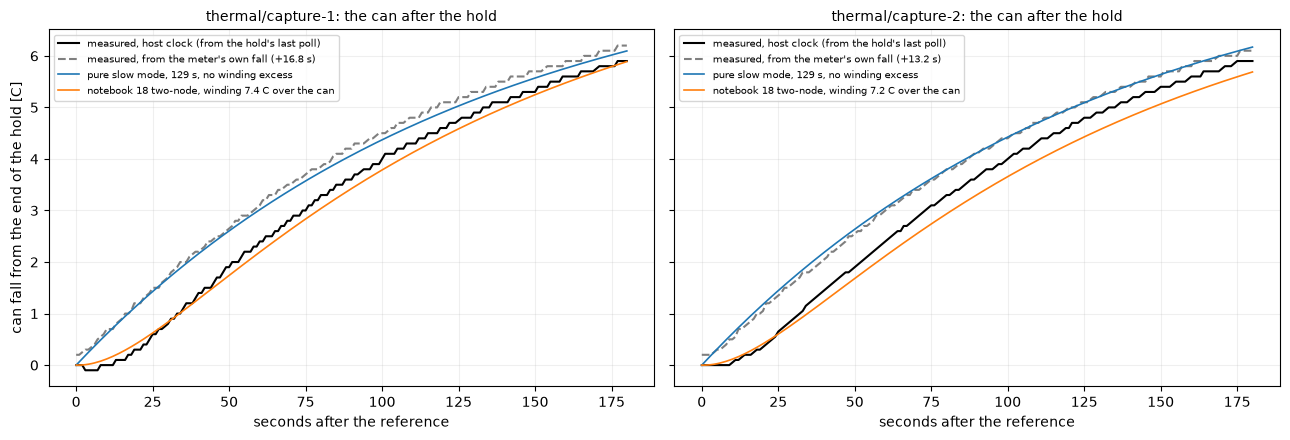

host clock                   from the meter's fall  \
hold thermal/capture-1 thermal/capture-2     thermal/capture-1   
s                                                                
10                 0.0              0.05                  0.70   
20                 0.3              0.35                  1.20   
30                 0.8              0.90                  1.70   
40                 1.4              1.45                  2.20   
60                 2.4              2.40                  3.10   
80                 3.3              3.30                  3.85   
120                4.6              4.60                  5.10   

                          pure slow mode                            two-node  \
hold thermal/capture-2 thermal/capture-1 thermal/capture-2 thermal/capture-1   
s                                                                              
10                0.50              0.60              0.61              0.12   
20                1.05              1.16              1.18              0.43   
30                1.60              1.68              1.70              0.83   
40                2.05              2.16              2.19              1.28   
60                3.00              3.01              3.05              2.19   
80                3.80              3.75              3.79              3.04   
120               5.00              4.91              4.97              4.44   

                        
hold thermal/capture-2  
s                       
10                0.12  
20                0.41  
30                0.81  
40                1.24  
60                2.12  
80                2.93  
120               4.28

thermal/capture-1: worst |measured - model| over +10/20/40/60 s, host clock: pure 0.86, two-node 0.21; from the meter's fall: pure 0.10, two-node 0.92 C
thermal/capture-2: worst |measured - model| over +10/20/40/60 s, host clock: pure 0.83, two-node 0.28; from the meter's fall: pure 0.14, two-node 0.88 C


In [11]:
# After the hold: how fast the can falls. The pure slow mode from the end-of-hold rise, notebook
# 18's two-node network driven by the hold's own power, and the meter on two clocks: the host's
# (the hold's last poll is the reference; the tool's console returned shortly after, centring done
# and torque off), and re-aligned to the meter's own first fall of 0.15 C, the way the analysis did.
QS = (10, 20, 30, 40, 60, 80, 120)
MF = "from the meter's fall"
rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, c in zip(axes, RUN):
    H, m = HOLD[c], MET[c]
    rise = H["c1"] - H["c0"]
    tq = np.arange(0, 181, 1.0)
    # the network from rest through the hold at its mean power, then nothing
    tw, tc, _ = net18.run(0.0, (0.0, 0.0, 0.0), [(0.0, H["te"] - H["ts"], H["p_w"])], (H["te"] - H["ts"]) + tq, 1.0, 0.0, alpha=0.0)
    fall_2n = tc[0] - tc
    plateau = m[(m.t_unix > H["te"] - 30) & (m.t_unix < H["te"])].can_c.median()
    t_fall = m[(m.t_unix > H["te"] - 5) & (m.can_c < plateau - 0.15)].t_unix.min()
    host = H["c1"] - tm.can_at(m, H["te"] + tq)
    meter = plateau - tm.can_at(m, t_fall + tq)
    pure = rise * (1 - np.exp(-tq / slow))
    ax.plot(tq, host, color="k", lw=1.5, label="measured, host clock (from the hold's last poll)")
    ax.plot(tq, meter, color="tab:grey", lw=1.5, ls="--", label=f"measured, from the meter's own fall (+{t_fall - H['te']:.1f} s)")
    ax.plot(tq, pure, color="tab:blue", lw=1.2, label=f"pure slow mode, {slow:.0f} s, no winding excess")
    ax.plot(tq, fall_2n, color="tab:orange", lw=1.2, label=f"notebook 18 two-node, winding {tw[0] - tc[0]:.1f} C over the can")
    for q in QS:
        k = int(q)
        rows.append({"hold": c, "s": q, "host clock": host[k], MF: meter[k], "pure slow mode": pure[k], "two-node": fall_2n[k]})
    txt = (DS.path / c / "report.out").read_text()
    back = float(re.findall(r"(\d{10}(?:\.\d+)?)\s*$", txt.strip())[0]) - H["te"]
    print(f"{c}: the tool's console returned {back:.1f} s after the hold's last poll; the meter's first 0.15 C fall came "
          f"{t_fall - H['te']:.1f} s after it; notebook 18's network has the winding {tw[0] - tc[0]:.1f} C over the can at the hold's end")
    ax.set_title(f"{c}: the can after the hold", fontsize=10)
    ax.set_xlabel("seconds after the reference")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7.5)
axes[0].set_ylabel("can fall from the end of the hold [C]")
plt.tight_layout()
plt.show()
DECAY = pd.DataFrame(rows).set_index(["hold", "s"])
display(DECAY.round(2).unstack(0))
for c in RUN:
    d = DECAY.loc[c].loc[[10, 20, 40, 60]]
    print(f"{c}: worst |measured - model| over +10/20/40/60 s, host clock: pure {np.abs(d['host clock'] - d['pure slow mode']).max():.2f}, "
          f"two-node {np.abs(d['host clock'] - d['two-node']).max():.2f}; from the meter's fall: pure {np.abs(d[MF] - d['pure slow mode']).max():.2f}, "
          f"two-node {np.abs(d[MF] - d['two-node']).max():.2f} C")

**What you are looking at.** The can's fall after each hold, measured two ways, against two
models. The black line puts time zero at the hold's last poll on the host's clock (the tool's console
returned 1.6 s later, with the shaft centred and torque off). The grey dashes put it at the meter's
own first fall of 0.15 C, which comes 16.8 and 13.2 s later. The blue line is a can with no heat
behind it, falling on the 129 s slow mode from where it stood. The orange is notebook 18's network
driven by the hold's own power, with its winding about 7 C over the can at the end.

The two clocks tell two different stories, and I cannot pick one from this data.

- **On the host clock the can holds flat for about 10 s and then follows the two-node network**,
  within 0.21 and 0.28 C over +10 to +60 s, while the pure decay misses by 0.86 and 0.83 C. That
  says the winding sat several degrees over the can and fed it after torque off.
- **From the meter's own fall the pure decay fits** within 0.10 and 0.14 C and the network misses by
  0.92 and 0.88 C. That says the winding held no excess over the can, the reading the bringup
  analysis took.

The 13 to 17 s between them is either the meter's packets running late against the host, or a
real lag in the can (heat behind it, or the bead under its tape). Open has the test that separates
them. The first changes nothing in section 3, where the can moves slowly, but it decides what $g$
should be.

In [12]:
def report_fit(c):
    # what the tool printed: its fitted R_th, tau and table encodings, and the residual
    txt = (DS.path / c / "report.out").read_text()
    g = int(re.search(r"th_g_q016\s+fitted\s+(\d+)", txt)[1])
    a = int(re.search(r"th_alpha_q24\s+fitted\s+(\d+)", txt)[1])
    return dict(g_q016=g, alpha_q24=a, r_th=float(re.search(r"th_g_q016.*?R_th ([\d.]+)", txt)[1]),
                tau=float(re.search(r"th_alpha_q24.*?tau ([\d.]+)", txt)[1]), form=re.search(r"fit\s+(.*)", txt)[1][:70],
                c_j=(lambda mt: float(mt[1]) if mt else np.nan)(re.search(r"C ([\d.]+) J/C", txt)))


rows = []
for c in RUN:
    t, _, _ = RUN[c]
    H = HOLD[c]
    rep = report_fit(c)
    free = tm.fit_free(t, W_UNIT)
    fixed = tm.fit_g(t, tau_s, W_UNIT)
    at_tool = tm.fit_g(t, rep["tau"], W_UNIT) if not np.isnan(rep["c_j"]) else dict(r_th=np.nan)
    # the can-anchored reference the re-validation gates on: the settled can rise, plus 1 C for the
    # winding over the can, less the NTC's own rise, per watt
    ref = (H["settled"] + 1.0 - H["d_ntc"]) / H["p_w"]
    rows.append({"hold": c, "tool printed R_th": rep["r_th"], "tool tau s": rep["tau"], "tool g_q016": rep["g_q016"],
                 "tool alpha_q24": rep["alpha_q24"], "free fit (port) R_th": free["r_th"], "free tau s": free["tau"],
                 "free g_q016": free["g_q016"], "free alpha_q24": free["alpha_q24"],
                 f"tau fixed {tau_s:.0f} s (port) R_th": fixed["r_th"], "fixed g_q016": fixed["g_q016"],
                 "tau fixed at the tool's (port) R_th": at_tool["r_th"],
                 "can-anchored reference C/W": ref, "family C/W": r_th, "tool's C J/C": rep["c_j"]})
FITS = pd.DataFrame(rows).set_index("hold")
display(FITS.round(2).T)
print("tool's fit lines: " + " | ".join(f"{c}: {report_fit(c)['form']}" for c in RUN))
print((DS.path / "thermal/capture-2" / "gates.out").read_text())

# what g sets in the firmware at the 280-count limit and a 28 C NTC: the bound and the boot prior
for g_cw in (r_th, FITS["can-anchored reference C/W"].mean()):
    f2 = dict(F, th_g_q016=g_cw * 65536 * W_UNIT * 100)
    print(f"g at {g_cw:.1f} C/W: bound x_max {x_max_c(28.0, f2):.1f} C, boot prior {x_max_c(28.0, f2) / 3:.1f} C, "
          f"rise check {x_max_c(28.0, f2) / 32:.2f} C/s")

hold,thermal/capture-1,thermal/capture-2
tool printed R_th,24.30,20.40
tool tau s,45.70,84.70
tool g_q016,579.00,485.00
tool alpha_q24,5872.00,3168.00
free fit (port) R_th,24.33,20.68
free tau s,45.72,89.47
free g_q016,579.00,493.00
free alpha_q24,5872.00,3000.00
tau fixed 128 s (port) R_th,28.57,23.91
fixed g_q016,680.00,569.00


tool's fit lines: thermal/capture-1: 463 s of tracked hold (28912 ticks) in 2 stretch(es), 1 cut between th | thermal/capture-2: g from 217 chunks at tau held 84.9 s (2 pass(es), the first at the tab
[rv1] hold 1791437927.0..1791438407.4 (480.4 s), seat pos 217-390, duty -5159 (15.7%), i median 261, i_lim min 280, fault max 0, flags [np.int64(0), np.int64(2)]
  first base r_hat 4089.0 vs r0 4078 (+0.27%), HOT flag bit3 seen: False
  G1: can 25.40 -> 33.60 (dCan +8.20), NTC 28.13 -> 29.38 (dNTC +1.25), P_W 0.2595 W (mean p 71407), L 480 s -> R_ref 31.4 C/W; R_th fit 20.4 -> -35.1% : FAIL
  G2 can fall after torque-off (meas/pred 129 s): +10s 0.05/0.61, +20s 0.35/1.18, +40s 1.45/2.19, +60s 2.40/3.05, +80s 3.30/3.79, +120s 4.60/4.97 : FAIL
  G2 info: meter-aligned off at torque-off +13.2 s; falls from plateau 33.60: +10s 0.50/0.61, +20s 1.05/1.18, +40s 2.05/2.19, +60s 3.00/3.05
  G3: 1 s bins 481, |dR| > 0.8%/s in 1 bins [(248, 1.35)]; raw copper rise 12.25 C (R 0.99706 -> 1.04354, +4.66%

**What you are looking at.** For each hold, what the tool printed, my port of the tool's free fit,
the same fit with $\tau$ held at the table's 128 s (and at the tool's own $\tau$ for the second
hold), the can-anchored reference the re-validation gates on, and the family. Then the tool's fit
line, the second hold's gate script output as the bench ran it, and what $g$ sets in the firmware at
two values.

- **The free fit is the tool's fit.** The port lands on the first hold's printed 579 and 5872
  exactly (the test pins it), $\tau$ 45.7 s and 24.33 C/W. A free $\tau$ off one 480 s hold comes
  out at whatever the contact steps in the hold make it. The port gives 89.47 s on the second.
- **With $\tau$ held at 128 s the first hold reads 28.57 C/W**, against a can-anchored reference of
  30.28. The second reads 23.91, against 31.41.
- **The second hold failed three of its four gates.** The reference is off by -35.1%, the can's
  cool-down fails on the host clock and passes on the meter's, and there was a 1.35% step in one
  second at 248 s with the copper rise 4.05 C over the can's. The tool printed 20.4 C/W with $\tau$
  84.7 s and a heat capacity of 4.16 J/C. My port at its 84.9 s reads 22.62, so the newer tool's fit
  is not the one ported here.
- **$g$ sets the bound and the prior.** At 63.0 C/W they are 27.1 and 9.0 C, at 30.8 they would be
  13.3 and 4.4 C, with the rise check at 0.85 and 0.41 C per second.

So the bench pins $\tau$ as the can's slow mode and the can's own ~31 C/W. It does not pin $g$,
because $g$ needs the winding's excess over the can, and that waits on the clock question. Two more
re-validation holds were planned after the second. They had not run when this notebook was built.

thermal/capture-1 family carry: 16.46 C at the hold's end
thermal/capture-1 free fit: 6.50 C at the hold's end
thermal/capture-1 tau-fixed fit: 7.47 C at the hold's end
thermal/capture-1: kernel excess 4.15 C at +30 s and 6.74 C at the end; T* - NTC at the end 6.89 C


thermal/capture-2 family carry: 15.87 C at the hold's end
thermal/capture-2 free fit: 5.31 C at the hold's end
thermal/capture-2 tau-fixed fit: 6.02 C at the hold's end
thermal/capture-2: kernel excess 3.93 C at +30 s and 4.97 C at the end; T* - NTC at the end 6.85 C


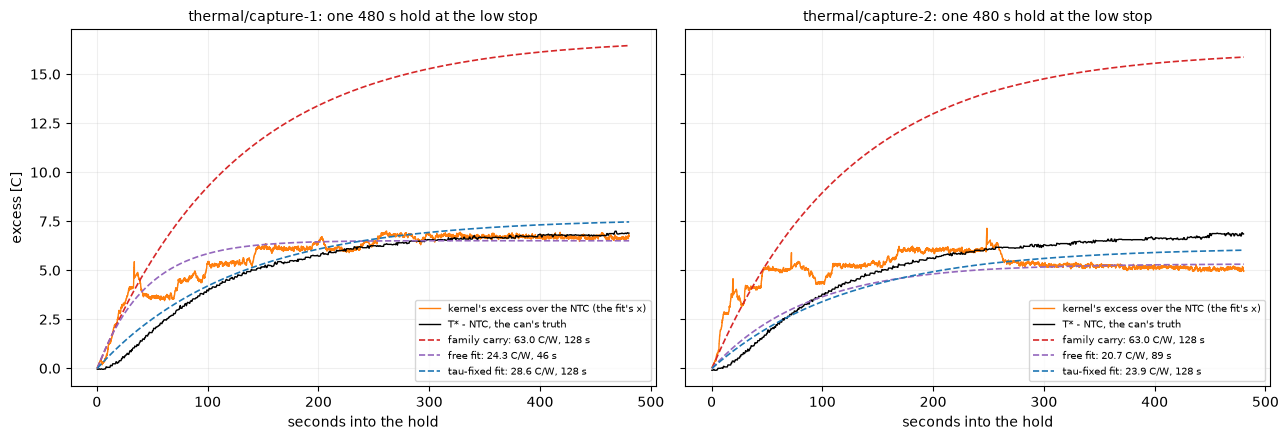

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, c in zip(axes, RUN):
    t, s, _ = RUN[c]
    H = HOLD[c]
    tt = t.t_unix - H["ts"]
    ax.plot(tt, t.x_cc / 100, color="tab:orange", lw=1, label="kernel's excess over the NTC (the fit's x)")
    m = MET[c][(MET[c].t_unix >= H["ts"]) & (MET[c].t_unix <= H["te"])]
    ntc = np.interp(m.t_unix, H["ntc"].index, H["ntc"].to_numpy())
    ax.plot(m.t_unix - H["ts"], m.can_c - REST[c]["offset"] - ntc, color="k", lw=1, label="T* - NTC, the can's truth")
    pw = (t.p * W_UNIT).rolling(200, min_periods=1).mean().to_numpy()
    for g_cw, tau, color, lab in ((r_th, tau_s, "tab:red", "family carry"),
                                  (FITS.loc[c, "free fit (port) R_th"], FITS.loc[c, "free tau s"], "tab:purple", "free fit"),
                                  (FITS.loc[c, f"tau fixed {tau_s:.0f} s (port) R_th"], tau_s, "tab:blue", "tau-fixed fit")):
        x = np.zeros(len(tt))
        dt = np.diff(tt.to_numpy(), prepend=tt.iloc[0])
        for k in range(1, len(tt)):
            x[k] = x[k - 1] + dt[k] / tau * (g_cw * pw[k] - x[k - 1])
        ax.plot(tt, x, color=color, lw=1.2, ls="--", label=f"{lab}: {g_cw:.1f} C/W, {tau:.0f} s")
        print(f"{c} {lab}: {x[-1]:.2f} C at the hold's end")
    k30 = np.searchsorted(tt.to_numpy(), 30.0)
    print(f"{c}: kernel excess {t.x_cc.iloc[k30] / 100:.2f} C at +30 s and {t.x_cc.iloc[-1] / 100:.2f} C at the end; "
          f"T* - NTC at the end {m.can_c.iloc[-1] - REST[c]['offset'] - ntc[-1]:.2f} C")
    ax.set_title(f"{c}: one 480 s hold at the low stop", fontsize=10)
    ax.set_xlabel("seconds into the hold")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7.5, loc="lower right")
axes[0].set_ylabel("excess [C]")
plt.tight_layout()
plt.show()

**What you are looking at.** Each hold's kernel excess over the NTC (orange, what the fit reads),
the can's truth $T^{\ast}$ less the NTC (black), and three first-order models driven by the hold's
own power, the family's, the free fit's and the $\tau$-fixed fit's. The family carry runs to 16.46
and 15.87 C, over twice the can's 6.89 and 6.85 C at the end, and that is what the carry would
say if a hold like this were read by carry alone. The kernel's excess is at 4.15 and 3.93 C after
30 s, well ahead of the can, and both holds show steps in it that the can does not have.

## 7. Validity envelope and accuracy

Everything above, as one table. The errors are against the can bead, so they inherit whatever the
bead is off by, and section 6's clock question.

In [14]:
g3, g4 = GAPS["oab/capture-1"], GAPS["oab/capture-2"]
offs = np.array([r["offset"] for r in REST.values()])
long4, short4 = g4[g4.gap_s > 200].carry_m_t, g4[g4.gap_s < 100].carry_m_t
rows = [
    ("base: board NTC against the can at rest", "rest offsets, 4 rests", f"{offs.min():+.2f} to {offs.max():+.2f} C",
     "the NTC rests over the can by this much; the shipped thermometer does not subtract it"),
    ("within a hold: the ratio at the end of a 480 s hold", "thermal holds, carried - T*",
     " / ".join(f"{v:+.2f}" for v in FAM["carried - T* C"]) + " C", "the second hold had a contact step in it (its gate G3)"),
    ("across a 240 s gap: the carry", "run 4, carried - T*", " / ".join(f"{v:+.2f}" for v in long4) + " C", "over-reads, grows gap to gap"),
    ("across a 30 s gap: the carry", "run 4, carried - T*", " / ".join(f"{v:+.2f}" for v in short4) + " C",
     "T* is no truth at 30 s: the winding has not reached the can"),
    ("across a 240 s gap, run 3 (one clean gap)", "run 3 gap 1", f"{g3.carry_m_t[0]:+.2f} C", "the later gaps carry hold3's false 80 C"),
    ("first reading after a reset", "boot logs, reading - T*", f"{BOOTACC.min():+.2f} to {BOOTACC.max():+.2f} C", "the prior reads high, then decays"),
    ("seat to seat at one stop (contact)", "R25 range, normal state", " / ".join(f"{v:.1f}" for v in CONTACT["max/min - 1 %"].iloc[:2]) + " %",
     "never a temperature: the base re-takes it at every seat"),
]
display(pd.DataFrame(rows, columns=["what", "data", "error", "note"]).set_index("what"))

,data,error,note
what,,,
base: board NTC against the can at rest,"rest offsets, 4 rests",-2.75 to -2.03 C,the NTC rests over the can by this much; the s...
within a hold: the ratio at the end of a 480 s hold,"thermal holds, carried - T*",-0.15 / -1.85 C,the second hold had a contact step in it (its ...
across a 240 s gap: the carry,"run 4, carried - T*",+0.05 / +1.36 / +2.12 C,"over-reads, grows gap to gap"
across a 30 s gap: the carry,"run 4, carried - T*",+3.06 / +5.30 C,T* is no truth at 30 s: the winding has not re...
"across a 240 s gap, run 3 (one clean gap)",run 3 gap 1,+1.14 C,the later gaps carry hold3's false 80 C
first reading after a reset,"boot logs, reading - T*",+6.34 to +6.35 C,"the prior reads high, then decays"
seat to seat at one stop (contact),"R25 range, normal state",2.0 / 2.7 %,never a temperature: the base re-takes it at e...


**What you are looking at.** One row per way the thermometer can be wrong, the data it comes from,
the error, and a note.

The envelope this covers is narrow, and every bit of it matters:

- **One MG90, one rev 2A board, the board on the bench beside the servo, free air, the DPS-150 at
  7.4 V.** The NTC is the board's. With the board inside a servo case the NTC may sit closer to the
  motor or hotter than it, and the rest offset changes with it.
- **Seats at the low stop only, at the 280-count limit, 0.26 to 0.29 W.** Every hold here sat at one
  stop. A seat elsewhere in the travel has its own contact level, which the design handles, but
  nothing here measured it.
- **Gaps of 30 and 240 s.** Longer gaps let the carry settle to the NTC, which is the base's error
  alone. Moves with power in them (the carry's other job) are not in this dataset at all.
- **Mounting.** $\tau$ and the can's ~31 C/W are this servo on this mount in room air. A horn, an
  arm or a bracket is a different can-to-air path.

## 8. What the firmware and the tools pin

The tests below are read straight out of the source, so the list cannot drift from it. The core
tests run the estimator on synthetic seats, several of them on the bench events above (hold3 is
`a_v_step_at_a_held_current_drops_the_base_without_a_temperature_step`, run 3's first-hold step is
`a_contact_step_inside_the_band_drops_the_base_on_its_rise_rate`, and the 9% first seat is
`a_nine_percent_first_seat_moves_the_reading_under_half_a_degree`). The kernel tests run the same
through the whole kernel. The ident tests pin the table encodings and the anchor.

In [15]:
def tests_in(path):
    # every #[test] fn in a Rust file, with the start of its doc comment when it has one
    src = (REPO / path).read_text().splitlines()
    out = []
    for k, ln in enumerate(src):
        mt = re.match(r"\s*fn ([a-z0-9_]+)\(", ln)
        if mt and any("#[test]" in src[j] for j in range(max(0, k - 3), k)):
            doc = []
            j = k - 1
            while j >= 0 and (src[j].strip().startswith("///") or src[j].strip().startswith("#[")):
                if src[j].strip().startswith("///"):
                    doc.insert(0, src[j].strip()[3:].strip())
                j -= 1
            out.append((mt[1], " ".join(doc)[:110]))
    return out


PINS = []
for path, keep in (("firmware/lib/core/src/estimator/thermal.rs", None),
                   ("firmware/lib/core/src/kernel/tests.rs", ("thermometer", "seat", "derate", "contact", "torque_off_carries")),
                   ("ident/src/thermometer.rs", None),
                   ("ident/src/exp/anchor.rs", None)):
    for name, doc in tests_in(path):
        if keep is None or any(k in name for k in keep):
            PINS.append({"file": path.split("src/")[-1], "test": name, "doc": doc})
PINS = pd.DataFrame(PINS)
with pd.option_context("display.max_colwidth", 120):
    display(PINS.set_index(["file", "test"]))
# the list docs/control-theory.md gives, checked against the source
doc = (REPO / "docs/control-theory.md").read_text()
sec = doc[doc.index("The tests that pin all of this"):]
sec = sec[:sec.index("###")]
named = re.findall(r"`([a-z0-9_]+)`", sec)
named = [n for n in named if n not in ("estimator", "thermal")]
missing = [n for n in named if n not in set(PINS.test)]
print(f"control-theory names {len(named)} tests; missing from the source: {missing or 'none'}")

doc
file                 test                                                                                                                                                                                
estimator/thermal.rs ntc_quadratic_tracks_the_beta_curve_within_a_degree_from_15_to_50_c                                                                                                                 
                     unset_reads_the_sentinel_and_never_a_temperature                                                                                                                                    
                     a_seat_bases_on_the_ntc_and_reads_the_ratio_rise                                                                                                                                    
                     a_seat_change_rebases_without_a_temperature_step                                                                                                                                    
                     a_current_shift_at_the_seat_rebases                                                                                                                                                 
                     a_contact_step_under_the_rate_bound_reads_as_heat_until_the_rebase    The documented blind spot: a one-vcount contact step inside one hold (+0.35% at 280 counts), under the rate bo
                     a_v_step_at_a_held_current_drops_the_base_without_a_temperature_step  Run 3 hold3 replayed: seated at a held 273 counts with the circuit 21% low (a brush bridging two segments), ba
                     a_contact_step_inside_the_band_drops_the_base_on_its_rise_rate        Run 3 hold0's step: the contact moves +1.4% inside a hold, inside the v band (+3.6 C by the ratio, 18x the adi
                     the_excess_over_the_ntc_is_held_under_the_limit_s_steady_excess       At the 280-count limit through the cold R at a 29 C NTC the winding holds at most 18.4 C over it (0.29 W at 63
                     the_rise_bound_goes_with_the_limit_s_power_over_a_floor               The rise bound is 4x the plant's adiabatic rise at the current limit, which goes with the limit's power: doubl
                     torque_off_carries_the_excess_to_the_ntc_on_tau                                                                                                                                     
                     boot_starts_the_carry_at_half_the_limit_s_steady_excess               The boot prior at the bench model's 280-count limit, 25 C NTC: half the steady excess, 280 x (4128 x 280 / 409
                     a_nine_percent_first_seat_moves_the_reading_under_half_a_degree       The seat that defeated the retired hot-boot band: +9% of contact over the cold R at the first seat after boot.
                     cold_check_flags_a_shifted_cloud_after_five_idle_seats                                                                                                                              
                     a_sixty_second_gap_is_carried_within_three_degrees_over_reading       The brief's gap pin against notebook 18's two-node plant (winding 1.3 J/C over 35 C/W to a 4.0 J/C can over 32
kernel/tests.rs      thermometer_without_a_model_reads_the_sentinel_and_never_derates      Without model constants the thermometer reads its sentinel and nothing derates, however hot the hold would rea
                     seat_change_rebases_the_ratio_without_a_temperature_step              A seat change with +1% of contact (the retired anchor read it as +2.6 C) re-bases on the carried temperature: 
                     a_derate_step_at_a_seat_reads_under_half_a_degree                     A derate step at the seat (the current drops an eighth or more while the duty holds) would read +17% of R as h
                     a_contact_step_inside_a_hold_is_rejected_on_its_rise_rate             A +1.5% contact step inside one hold (+3.9 C by the ratio) rises fa

control-theory names 19 tests; missing from the source: none


**What you are looking at.** Every test, with the start of its doc comment where it has one,
and a check that the list in docs/control-theory.md names only tests that exist.

Two things the bench raised have no test. Nothing pins the carry across a 240 s torque-off gap
against a can witness, and `a_sixty_second_gap_is_carried_within_three_degrees_over_reading` pins a
loaded move against notebook 18's network instead, which is the model section 6 cannot confirm.
And nothing pins the boot prior's error against a winding that is actually warm.

## What is open, and the next experiment

- **The can's clock after torque off (section 6).** The can's fall starts 13 to 17 s after the hold
  ends on the host clock. The candidates are (a) the meter's packets lag the host's clock by that much,
  (b) the winding holds several degrees over the can and feeds it after torque off, (c) the bead
  under its tape lags the can. To separate them, with everything at rest, touch the bead with a
  warm object at a moment the host logs (a keypress in the same log), and read the lag. (a) shows
  the same 13 to 17 s on the bare bead. (b) and (c) show none, and then a second bead on the
  winding of the teardown motor through one 480 s hold separates them. (b) puts it about 7 C over
  the can at the end, (c) puts it with the can. The answer decides whether $g$ is about 31 or about
  40 C/W over the NTC.
- **The carry over-reads across 240 s gaps, more each gap (section 3).** +0.05, +1.36, +2.12 C in
  run 4. The candidates are (a) $g$ at 63 makes the carry leave each hold too high, (b) the reading at the
  end of each hold is itself high (contact under the rise check), (c) the base offset of 2 C moves
  with the board's warming. A host replay costs no bench time. Run the shipped carry over run 4's
  logged power from each hold's last reading with $g$ at 31 and at 63 and compare each base to
  $T^{\ast}$. (a) predicts the 31 replay lands within half a degree, (b) predicts both replays miss
  by the same amount as the hold-end reading's own error against $T^{\ast}$.
- **The base offset, 2.03 to 2.75 C (section 3).** The candidates are (a) the board warms itself (the
  regulator and the MCU) over the room, (b) the bead in room air reads under the can. A second bead
  on the NTC's body at rest separates them. (a) puts that bead with the NTC, (b) puts it with the
  can bead and the can bead low.
- **The second thermal hold's contact step (section 6)** and the re-validation it started. Two more
  holds at the same seat, as the bringup re-validation plans, each with its gates, and a fit
  through the median $g$ only if all three agree within 25%.
- **The boot prior's error on a hot winding.** Both boots here had the winding within 3 C of the
  NTC. A reset right after a hold long and hard enough to put the winding 15 C over the NTC, with
  the bead on the can, says whether the prior's "half-covered" holds up.

## Caveats

- **One servo, one board, one long day.** The contact's behaviour in particular is this motor's.
- **Five images.** Run 3 predates the guards, and the first-seat holds ran the retired boot rule.
  Only the boot logs and the second thermal hold ran exactly the shipped image. Run 4 differs from
  it in the boot rule only, by the commit history.
- **The bead is the only truth and it was never graded.** One K bead, taped to the can, in room air,
  read over Bluetooth. Its clock against the host is the open question of section 6.
- **The rest offsets are medians over 180 s at the end of each rest.** They assume the board and the
  can were both flat by then. The can's sd over those windows was 0.02 to 0.07 C.
- **Some meter files are cut.** The thermal holds' and boot logs' meter files are slices of the
  session's one log around each capture, and the second hold's slice ends 300 s after it, because
  the bench was still logging when the data was copied.
- **The tool's fits are ported only as the first hold's tool ran them.** The newer tool behind the
  second hold's 20.4 C/W is not reproduced here.